In [1]:
#imports:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import read_spe as spe

In [2]:
#read in undoped film data for 730nm
#p aka power, # for mW
p01 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p01_2024-05-17-164455.txt", sep="\t")
p1 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p1_2024-05-17-163134.txt", sep="\t")
p002 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p002_2024-05-17-165103.txt", sep="\t")
p2 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p2_2024-05-17-162655.txt", sep="\t")
p05 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p05_2024-05-17-163553.txt", sep="\t")
p5 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p5_2024-05-17-162241.txt", sep="\t")
p10 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p10_2024-05-17-161718.txt", sep="\t")
p025 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p025_2024-05-17-164030.txt", sep="\t")

In [3]:
#read in undoped settings data for 730nm
#sp aka settings power
sp01 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p01_2024-05-17-164455_SETTINGS.txt", header=None,sep=":")
sp1 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p1_2024-05-17-163134_SETTINGS.txt", header=None,sep=":")
sp002 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p002_2024-05-17-165103_SETTINGS.txt",header=None,sep=":")
sp2 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p2_2024-05-17-162655_SETTINGS.txt", header=None,sep=":")
sp05 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p05_2024-05-17-163553_SETTINGS.txt", header=None,sep=":")
sp5 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p5_2024-05-17-162241_SETTINGS.txt", header=None,sep=":")
sp10 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p10_2024-05-17-161718_SETTINGS.txt", header=None,sep=":")
sp025 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p025_2024-05-17-164030_SETTINGS.txt", header=None,sep=":")

In [4]:
#add all undoped files to a list in order of increasing power
undoped_730 = [p002, p01, p025, p05, p1, p2, p5, p10]

#add all settings files to a list in order of increasing power
undoped_settings_730 = [sp002, sp01, sp025, sp05, sp1, sp2, sp5, sp10]

In [5]:
#find average voltage for each undoped file, add them to a new list
#do the same with uncertainties
averageVoltageUndoped = []
for i in range(len(undoped_730)):
    averageVoltageUndoped.append(undoped_730[i].iloc[:,2].mean())

In [6]:
#convert power meter range (W) to mW
for i in range(len(undoped_settings_730)):
   undoped_settings_730[i].loc[3,1] = undoped_settings_730[i].loc[3,1]*1000
#Erin's code says divide it by 2, not really sure why 
#power = voltage x power range / 2
#convert from V to mW
averagePowerUndoped = []
uncertaintyPowerUndoped = []
for i in range(len(undoped_730)):
    averagePowerUndoped.append(averageVoltageUndoped[i] * ((undoped_settings_730[i].loc[3,1])/2))
    uncertaintyPowerUndoped.append((undoped_730[i].iloc[:,2] * ((undoped_settings_730[i].loc[3,1])/2)).std() / np.sqrt(103))

In [7]:
#find average counts per frame
averageCountsUndoped = []
uncertaintyCountsUndoped = []
cpsUndoped = []
uncertaintyCpsUndoped = []
for i in range(len(undoped_730)):
    averageCountsUndoped.append((undoped_730[i].iloc[:,4].mean()))
    uncertaintyCountsUndoped.append((undoped_730[i].iloc[:,4].std()))

#now counts per second, divide average by exposure time (from settings files)
for i in range(len(averageCountsUndoped)):
    cpsUndoped.append(averageCountsUndoped[i]/undoped_settings_730[i].iloc[1,1])
    uncertaintyCpsUndoped.append((uncertaintyCountsUndoped[i]/undoped_settings_730[i].iloc[1,1])/np.sqrt(103))

In [8]:
#now onto doped! 
#read in doped data files
#dp aka doped power
dp01 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_tenthmW_2024-03-27-175126.txt", sep="\t")
dp1 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_1mW_2024-03-27-173810.txt", sep="\t")
dp002 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_2hundredthsmW_2024-03-27-175524.txt", sep="\t")
dp2 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_2mW_2024-03-27-173333.txt", sep="\t")
dp05 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_halfmW_2024-03-27-174210.txt", sep="\t")
dp5 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_5mW_2024-03-27-172941.txt", sep="\t")
dp10 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_10mW_2024-03-27-172322.txt", sep="\t")
dp025 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_quartermW_2024-03-27-174656.txt", sep="\t")

In [9]:
#read in doped settings
#sdp aka settings doped power
sdp01 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_tenthmW_2024-03-27-175126_SETTINGS.txt", header=None,sep=":")
sdp1 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_1mW_2024-03-27-173810_SETTINGS.txt", header=None,sep=":")
sdp002 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_2hundredthsmW_2024-03-27-175524_SETTINGS.txt",header=None,sep=":")
sdp2 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_2mW_2024-03-27-173333_SETTINGS.txt", header=None,sep=":")
sdp05 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_halfmW_2024-03-27-174210_SETTINGS.txt", header=None,sep=":")
sdp5 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_5mW_2024-03-27-172941_SETTINGS.txt", header=None,sep=":")
sdp10 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_10mW_2024-03-27-172322_SETTINGS.txt", header=None,sep=":")
sdp025 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_quartermW_2024-03-27-174656_SETTINGS.txt", header=None,sep=":")

In [10]:
#make lists for doped
doped_730 = [dp002, dp01, dp025, dp05, dp1, dp2, dp5, dp10]

#add all settings files to a list in order of increasing power
doped_settings_730 = [sdp002, sdp01, sdp025, sdp05, sdp1, sdp2, sdp5, sdp10]

In [11]:
#find average voltage for each doped file
averageVoltageDoped = []
for i in range(len(doped_730)):
    averageVoltageDoped.append(doped_730[i].iloc[:,2].mean())

In [12]:
#convert power meter range (W) to mW
for i in range(len(doped_settings_730)):
   doped_settings_730[i].loc[3,1] = doped_settings_730[i].loc[3,1]*1000
#convert from V to mW
averagePowerDoped = []
uncertaintyPowerDoped = []
for i in range(len(doped_730)):
    averagePowerDoped.append(averageVoltageDoped[i] * ((doped_settings_730[i].loc[3,1])/2))
    uncertaintyPowerDoped.append((doped_730[i].iloc[:,2] * ((doped_settings_730[i].loc[3,1])/2)).std()/np.sqrt(103))

In [13]:
#find average counts per frame
#cps for counts per second
#also find uncertainties here
averageCountsDoped = []
uncertaintyCountsDoped =[]
cpsDoped = []
uncertaintyCpsDoped = []
for i in range(len(doped_730)):
    averageCountsDoped.append((doped_730[i].iloc[:,4].mean()))
    uncertaintyCountsDoped.append((doped_730[i].iloc[:,4].std()))
#now counts per second, divide average by exposure time (from settings files)
for i in range(len(averageCountsDoped)):
    cpsDoped.append(averageCountsDoped[i]/doped_settings_730[i].iloc[1,1])
    uncertaintyCpsDoped.append((uncertaintyCountsDoped[i]/doped_settings_730[i].iloc[1,1])/np.sqrt(103))

In [14]:
#now read in bias data (no film)
bias = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-04-11 Bias for Laser Power Scans\Bias_LPS_2024-04-11-105342.txt", sep="\t")
bias_settings = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-04-11 Bias for Laser Power Scans\Bias_LPS_2024-04-11-105342_SETTINGS.txt", header=None, sep=":")
#find average counts
bias_avg_counts = bias.iloc[:,4].mean()
#find counts per second
bias_cps = bias_avg_counts / .00001
#uncertainty
bias_uncertainty = np.std(bias.iloc[:,4]) / np.sqrt(103)

In [15]:
#subtract bias from doped and undoped datas
cpsDopedNoBias = []
for i in cpsDoped:
    cpsDopedNoBias.append(i-bias_cps)
cpsUndopedNoBias = []
for i in cpsUndoped:
    cpsUndopedNoBias.append(i-bias_cps)

In [16]:
#rescaling values to make curve_fit work (they're too big!!)
y_scale = 1E10
cpsDopedScaled = np.array(cpsDoped) / y_scale
cpsUndopedScaled = np.array(cpsUndoped) / y_scale
#no bias values
cpsDopedScaledNB = np.array(cpsDopedNoBias) / y_scale
cpsUndopedScaledNB = np.array(cpsUndopedNoBias) / y_scale

In [17]:
#dropping the final 2 points on the doped film since they appear to be at saturation
averagePowerDopedGraph = averagePowerDoped[0:5]
cpsDopedGraph = cpsDopedScaled[0:5]
#no bias version
cpsDopedGraphNB = cpsDopedScaledNB[0:5]

In [18]:
#fit curves
def linear(m,x,b):
    return ( m * x ) + b
x_fit = np.linspace(0,12)
#undoped fitting
best, ignore = curve_fit(linear, averagePowerUndoped, cpsUndopedScaled)
slope_undoped = best[0]
offset_undoped = best[1]
fit_undoped = linear(x_fit, slope_undoped, offset_undoped)
#doped fitting
best2, ignore = curve_fit(linear, averagePowerDopedGraph, cpsDopedGraph)
slope_doped = best2[0]
offset_doped = best2[1]
fit_doped = linear(x_fit, slope_doped, offset_doped)
#vs no bias versions
#undoped fitting
best3, ignore = curve_fit(linear, averagePowerUndoped, cpsUndopedScaledNB)
slope_undopedNB = best3[0]
offset_undopedNB = best3[1]
fit_undopedNB = linear(x_fit, slope_undopedNB, offset_undopedNB)
#doped fitting
best4, ignore = curve_fit(linear, averagePowerDopedGraph, cpsDopedGraphNB)
slope_dopedNB = best4[0]
offset_dopedNB = best4[1]
fit_dopedNB = linear(x_fit, slope_dopedNB, offset_dopedNB)

In [19]:
#rescale
fit_undoped = fit_undoped * y_scale
fit_doped = fit_doped * y_scale
#no bias rescaling
fit_undopedNB = fit_undopedNB * y_scale
fit_dopedNB = fit_dopedNB * y_scale

In [20]:
#find the difference btwn doped and undoped
#with bias
difference = np.array(fit_doped) - np.array(fit_undoped)
#without bias
differenceNB = fit_dopedNB - fit_undopedNB
#Assuming bias is constant across the graph, make a list of bias y values to graph (to match length of x_fit)
bias_graphing = []
for i in range(0,50):
    bias_graphing.append(bias_cps)

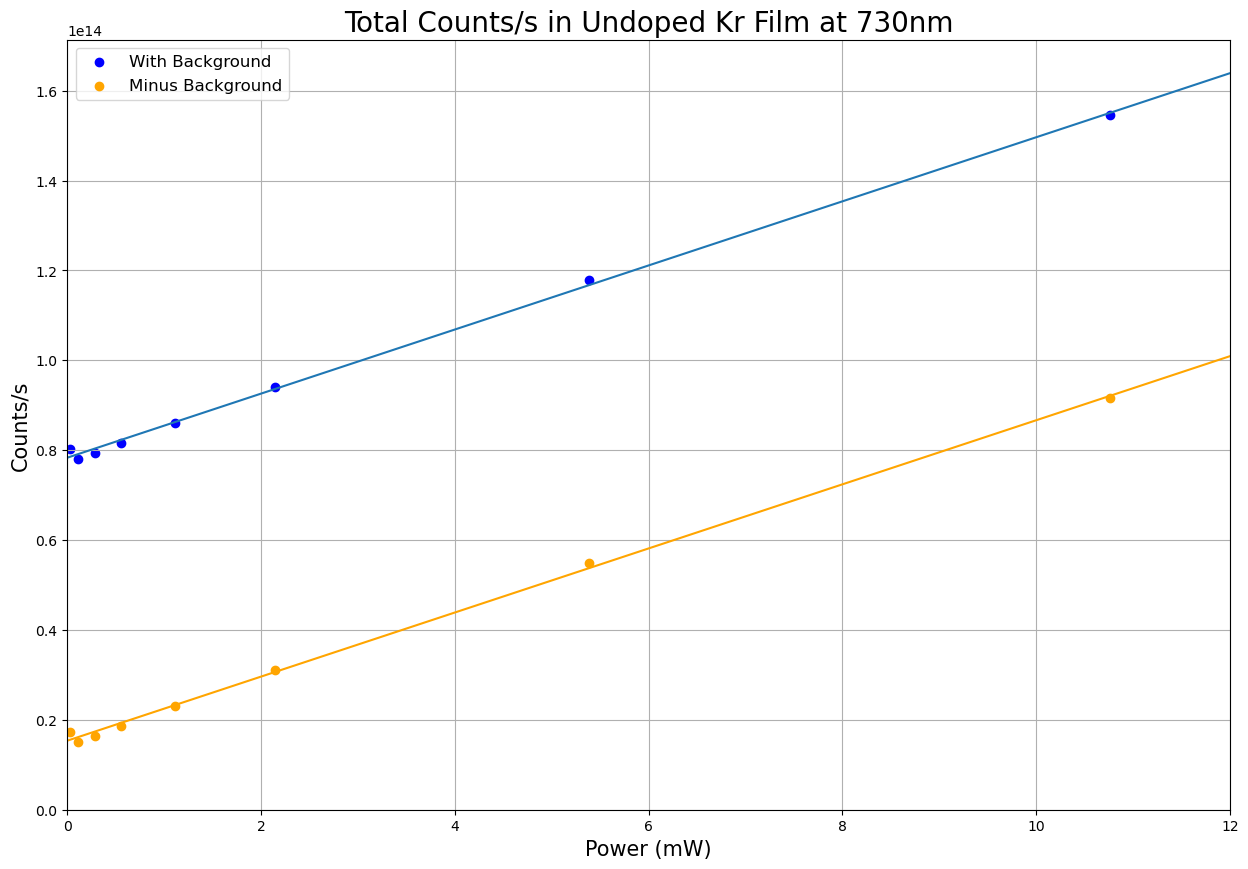

y = 1.54e+13 x + 1.71e+13


In [21]:
#plotting undoped
plt.figure(figsize=(15,10))
#with bias
plt.scatter(averagePowerUndoped, np.array(cpsUndoped), label="With Background", color='blue')
plt.errorbar(averagePowerUndoped, np.array(cpsUndoped),xerr=uncertaintyPowerUndoped, yerr=uncertaintyCpsUndoped,linestyle='none', color='blue')
plt.plot(x_fit, fit_undoped)
#without bias
plt.scatter(averagePowerUndoped, cpsUndopedNoBias, label="Minus Background",color='orange')
plt.errorbar(averagePowerUndoped, np.array(cpsUndopedNoBias), xerr=uncertaintyPowerUndoped, yerr=uncertaintyCpsUndoped + bias_uncertainty, linestyle='none', color='orange')
plt.plot(x_fit, fit_undopedNB,color='orange')
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.grid()
plt.title("Total Counts/s in Undoped Kr Film at 730nm", fontsize=20)
plt.xlim(0,12)
plt.ylim(0)
plt.legend(fontsize=12)
plt.show()
print("y =", "{:.2e}".format(fit_undopedNB[0]), "x +", "{:.2e}".format(fit_undopedNB[1]))

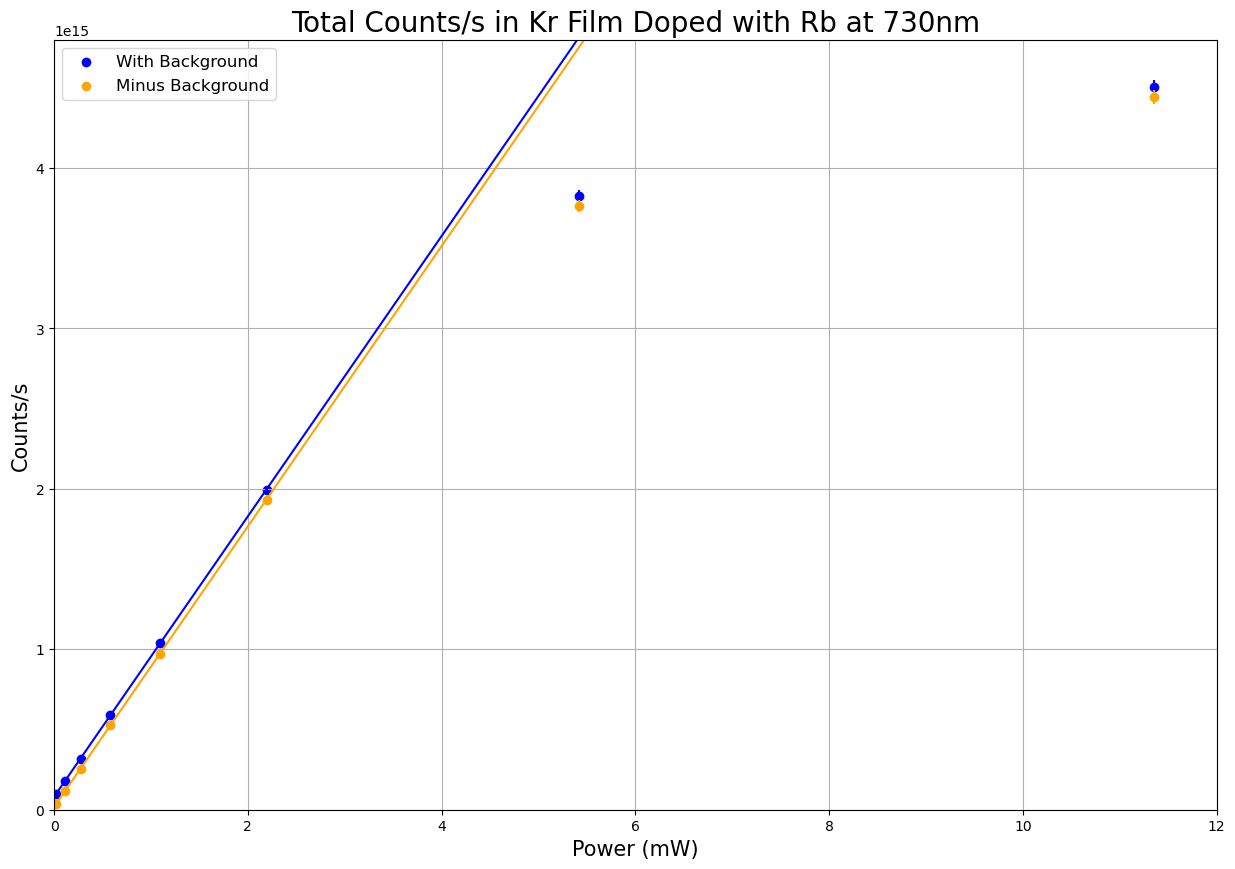

y = 1.87e+13 x + 2.33e+14
3.76e+15


In [22]:
#plotting doped
plt.figure(figsize=(15,10))
plt.title("Total Counts/s in Kr Film Doped with Rb at 730nm", fontsize=20)
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.grid()
#with bias
plt.scatter(averagePowerDoped, cpsDoped, label="With Background", color='blue')
plt.errorbar(averagePowerDoped, cpsDoped, xerr=uncertaintyPowerDoped, yerr=uncertaintyCpsDoped, linestyle='none', color='blue')
plt.plot(x_fit, fit_doped, color='blue')
#without bias
plt.scatter(averagePowerDoped, cpsDopedNoBias, label="Minus Background",color='orange')
plt.plot(x_fit, fit_dopedNB, color='orange')
plt.errorbar(averagePowerDoped, cpsDopedNoBias, xerr=uncertaintyPowerDoped, yerr=uncertaintyCpsDoped + bias_uncertainty, linestyle='none', color='orange')
plt.xlim(0,12)
plt.ylim(0,4.8E15)
plt.legend(fontsize=12)
plt.show()
print("y =", "{:.2e}".format(fit_dopedNB[0]), "x +", "{:.2e}".format(fit_dopedNB[1]))
print("{:.2e}".format(cpsDopedNoBias[6]))

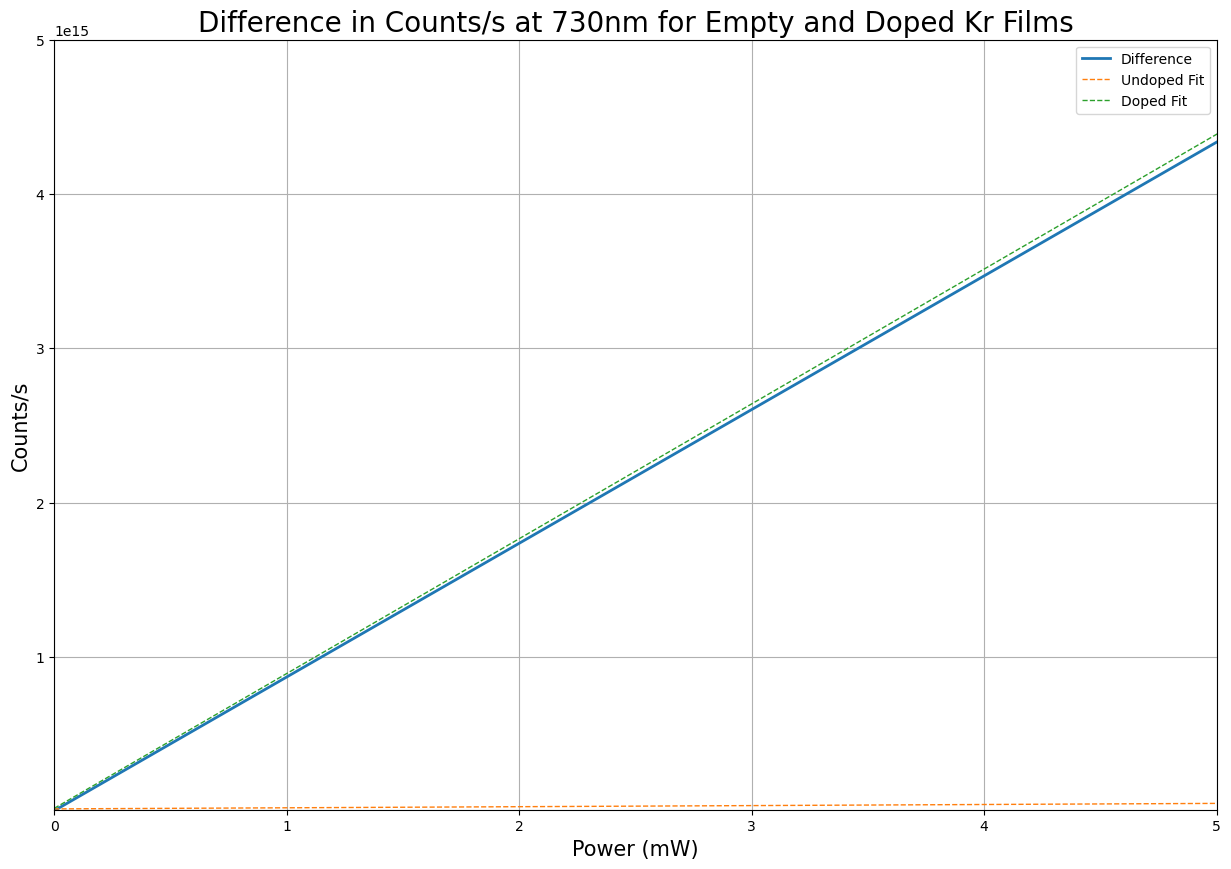

y = 3.29e+12 x + 2.16e+14


In [23]:
#plt.plot(x_fit, (difference - bias_cps))
plt.figure(figsize=(15,10))
plt.plot(x_fit, differenceNB, label='Difference', linewidth=2)
plt.title("Difference in Counts/s at 730nm for Empty and Doped Kr Films", fontsize=20)
plt.xlabel("Power (mW)",fontsize=15)
plt.ylabel("Counts/s",fontsize=15)
plt.xlim(0,5)
plt.ylim(1E13,.5E16)
plt.grid()
plt.plot(x_fit, fit_undopedNB,linewidth=1,linestyle='--',label='Undoped Fit')
plt.plot(x_fit, fit_dopedNB, linewidth=1,linestyle='--', label='Doped Fit')
plt.legend()
plt.show()
print("y =","{:.2e}".format(differenceNB[0]),"x +", "{:.2e}".format(differenceNB[1]))

In [24]:
#read in undoped CCD files
ccd01 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p01_IMF_Data_ 2024-05-17 16_45_34.spe")
ccd01 = spe.SpeReference.get_data(ccd01)
ccd1 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p1_IMF_Data_ 2024-05-17 16_32_30.spe")
ccd1 = spe.SpeReference.get_data(ccd1)
ccd002 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p002_IMF_Data_ 2024-05-17 16_51_46.spe")
ccd002 = spe.SpeReference.get_data(ccd002)
ccd2 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p2_IMF_Data_ 2024-05-17 16_27_38.spe")
ccd2 = spe.SpeReference.get_data(ccd2)
ccd05 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p05_IMF_Data_ 2024-05-17 16_36_39.spe")
ccd05 = spe.SpeReference.get_data(ccd05)
ccd5 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p5_IMF_Data_ 2024-05-17 16_23_24.spe")
ccd5 = spe.SpeReference.get_data(ccd5)
ccd10 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p10_IMF_Data_ 2024-05-17 16_17_58.spe")
ccd10 = spe.SpeReference.get_data(ccd10)
ccd025 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p025_IMF_Data_ 2024-05-17 16_41_16.spe")
ccd025 = spe.SpeReference.get_data(ccd025)


In [25]:
#read in doped CCD files
dccd1 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LPS_1mW_2024-03-27 17_38_44.spe")
dccd1 = spe.SpeReference.get_data(dccd1)
dccd01 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LPS_tenthmW_2024-03-27 17_51_58.spe")
dccd01 = spe.SpeReference.get_data(dccd01)
dccd002 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LPS_2hundredthsmW_2024-03-27 17_55_55.spe")
dccd002 = spe.SpeReference.get_data(dccd002)
dccd2 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LPS_2mW_2024-03-27 17_34_07.spe")
dccd2 = spe.SpeReference.get_data(dccd2)
dccd05 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LPS_halfmW_2024-03-27 17_43_15.spe")
dccd05 = spe.SpeReference.get_data(dccd05)
dccd5 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LPS_5mW_2024-03-27 17_30_14.spe")
dccd5 = spe.SpeReference.get_data(dccd5)
dccd10 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LPS_10mW_ 2024-03-27 17_24_59.spe")
dccd10 = spe.SpeReference.get_data(dccd10)
dccd025 = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LPS_quartermW_2024-03-27 17_47_31.spe")
dccd025 = spe.SpeReference.get_data(dccd025)



In [26]:
#add to a list
undoped_ccd = [ccd002, ccd01, ccd025, ccd05, ccd1, ccd2, ccd5, ccd10]
doped_ccd = [dccd002, dccd01, dccd025, dccd05, dccd1, dccd2, dccd5, dccd10]

In [27]:
#set region of interest (ROI)
#I'm using Erin's 
roi_x1 = 390
roi_x2 = 700
roi_y1 = 450
roi_y2 = 700

In [28]:
#create a list for the ROI files 
undoped_roi = []
doped_roi = []
#cut each CCD SPE file down to the ROI, add it to the list
for i in range(len(undoped_ccd)):
    undoped_roi.append(undoped_ccd[i][0][:, roi_y1:roi_y2 + 1, roi_x1:roi_x2 + 1])
    doped_roi.append(doped_ccd[i][0][:, roi_y1:roi_y2 + 1, roi_x1:roi_x2 + 1])

In [29]:
avg_counts_rois = []
avg_counts_rois_doped = []
#Take the sum of each frame of each file - then take the mean of all 103 sums to get one value per file. 
for i in range(len(undoped_roi)):
    avg_counts_rois.append(np.mean(np.sum(undoped_roi[i], axis=(1,2))))
for i in range(len(doped_roi)):
    avg_counts_rois_doped.append(np.mean(np.sum(doped_roi[i], axis=(1,2))))

In [30]:
ccd_cps = []
dccd_cps = []
#divide by exposure time (10 us)
for i in range(len(avg_counts_rois)):
    ccd_cps.append(avg_counts_rois[i]/.00001)
for i in range(len(avg_counts_rois_doped)):
    dccd_cps.append(avg_counts_rois_doped[i]/.00001)


In [31]:
#read in bias data from SPE files
ccd_bias = spe.SpeReference(r"I:\projects\spinlab_data\IMF Data\2024-04-11 Bias for Laser Power Scans\IMF_Data_ 2024-04-11 10_54_58.spe")
ccd_bias = spe.SpeReference.get_data(ccd_bias)
ccd_bias_settings = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-04-11 Bias for Laser Power Scans\Bias_LPS_2024-04-11-105342_SETTINGS.txt", header=None, sep=":")

In [32]:
#cut bias file down to ROI
bias_roi = ccd_bias[0][:,roi_y1:roi_y2 + 1, roi_x1:roi_x2 + 1]
#take the average of the sum of the ROI counts per frame in the file
avg_bias_roi = np.mean(np.sum(bias_roi,axis=(1,2)))
bias_uncertainty_ccd = (np.std(np.sum(bias_roi, axis=(1,2))))/0.00001

#divide by exposure time to get bias counts/s
avg_bias_roi = avg_bias_roi/.00001
print(avg_bias_roi)
#remove laser shuttered numbers (bias) from data
ccd_cps_no_bias = np.array(ccd_cps)-avg_bias_roi
dccd_cps_no_bias = np.array(dccd_cps)-avg_bias_roi
print(bias_uncertainty_ccd)

4688513109670.986
1187399090.7836378


In [33]:
#rescale
ccd_cps_NB_scaled = ccd_cps_no_bias / y_scale
dccd_cps_NB_scaled = dccd_cps_no_bias / y_scale

ccd_cps_scaled = np.array(ccd_cps) / y_scale
dccd_cps_scaled = np.array(dccd_cps) / y_scale
#drop last two points for curve_fit 
cpsDopedGraphCCD = dccd_cps_NB_scaled[0:5]


In [34]:
#logarithmic curve fitting 
x_fit_log = np.linspace(.01,12)
def log(x,m,b):
    return m * np.log(x) + b
best6, ignore = curve_fit(log, averagePowerDoped, dccd_cps_NB_scaled)
log_dopedCCD = best6[0]
log_offset_dopedCCD = best6[1]
log_fit_dopedCCD = log(x_fit_log, log_dopedCCD, log_offset_dopedCCD)

#linear curve for doped
best5, ignore = curve_fit(linear, averagePowerDoped, dccd_cps_NB_scaled)
slope_dopedCCD = best5[0]
offset_dopedCCD = best5[1]
linear_fit_dopedCCD = linear(x_fit, slope_dopedCCD, offset_dopedCCD)
#linear curve for dope w/out last two points
best7,ignore = curve_fit(linear, averagePowerDopedGraph, cpsDopedGraphCCD)
graph_slope_dopedCCD = best7[0]
graph_offset_dopedCCD = best7[1]
linear_graph_dopedCCD = linear(x_fit, graph_slope_dopedCCD, graph_offset_dopedCCD)
#linear curve for undoped
best8, ignore = curve_fit(linear, averagePowerUndoped, ccd_cps_NB_scaled)
slope_undopedCCD = best8[0]
offset_undopedCCD = best8[1]
fit_undopedCCD = linear(x_fit, slope_undopedCCD, offset_undopedCCD)

#curve fitting for biased data for comparison
best9, ignore = curve_fit(linear, averagePowerUndoped, ccd_cps_scaled)
slope_undoped_biased = best9[0]
offset_undoped_biased = best9[1]
fit_undoped_biased = linear(x_fit, slope_undoped_biased, offset_undoped_biased)

best10, ignore = curve_fit(linear, averagePowerDopedGraph, dccd_cps_scaled[0:5])
slope_doped_biased = best10[0]
offset_doped_biased = best10[1]
fit_doped_biased = linear(x_fit, slope_doped_biased, offset_doped_biased)

In [35]:
#uncertainties
#power uncertainties are the same
#cps
uncertaintyCountsUndopedCCD = []
uncertaintyCountsDopedCCD = []
#uncertainty for counts is the standard deviation of the sum per frame for each power, divided by number of frames
#find standard deviations
for i in range(len(undoped_roi)):
    uncertaintyCountsUndopedCCD.append(np.std
                                       (np.sum(undoped_roi[i], axis=(1,2)) /0.00001))
for i in range(len(doped_roi)):
    uncertaintyCountsDopedCCD.append(np.std(np.sum(doped_roi[i], axis=(1,2))/0.00001))
#divide standard deviations by sqrt(103)   
uncertainty_undopedROI = []
uncertainty_dopedROI = []
for i in range(len(uncertaintyCountsUndopedCCD)):
    uncertainty_undopedROI.append((uncertaintyCountsUndopedCCD[i])/np.sqrt(103))
for i in range(len(uncertaintyCountsDopedCCD)):
    uncertainty_dopedROI.append((uncertaintyCountsDopedCCD[i]/np.sqrt(103)))

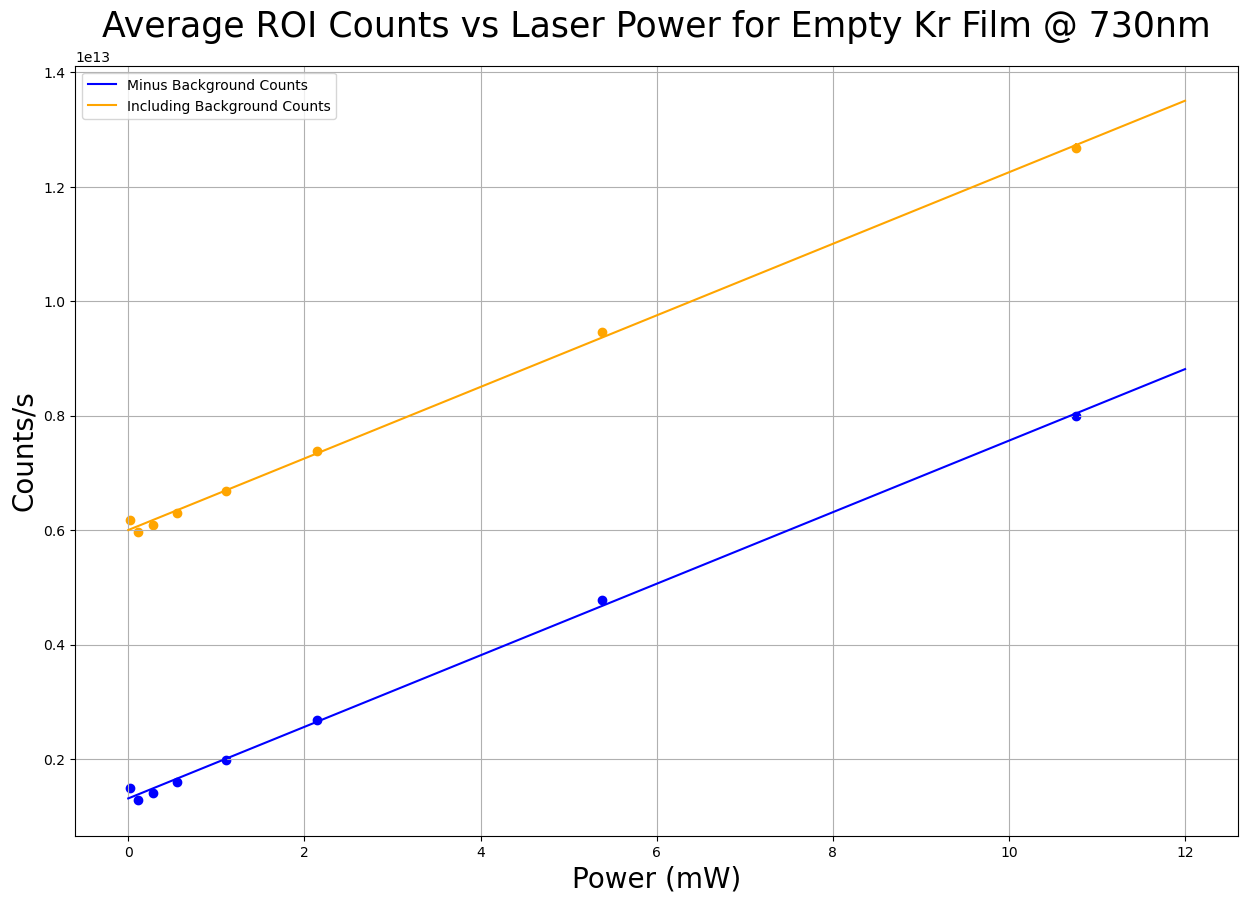

In [48]:
#plot
plt.figure(figsize=(15,10))
plt.scatter(averagePowerUndoped, ccd_cps_no_bias, color='blue')
plt.errorbar(averagePowerUndoped, ccd_cps_no_bias, xerr=uncertaintyPowerUndoped, yerr=uncertainty_undopedROI+bias_uncertainty_ccd, linestyle='none', color='blue')
plt.plot(x_fit, fit_undopedCCD*y_scale, label="Minus Background Counts", color='blue')
plt.plot(x_fit, fit_undoped_biased*y_scale, label="Including Background Counts",color='orange')
plt.scatter(averagePowerUndoped, ccd_cps,color='orange')
plt.errorbar(averagePowerUndoped, ccd_cps, xerr=uncertaintyPowerUndoped, yerr=uncertainty_undopedROI, linestyle='none', color='orange')

plt.grid()
plt.title("Average ROI Counts vs Laser Power for Empty Kr Film @ 730nm", fontsize=25, pad=10)
plt.xlabel("Power (mW)",fontsize=20)
plt.ylabel("Counts/s",fontsize=20)
plt.legend()
plt.show()

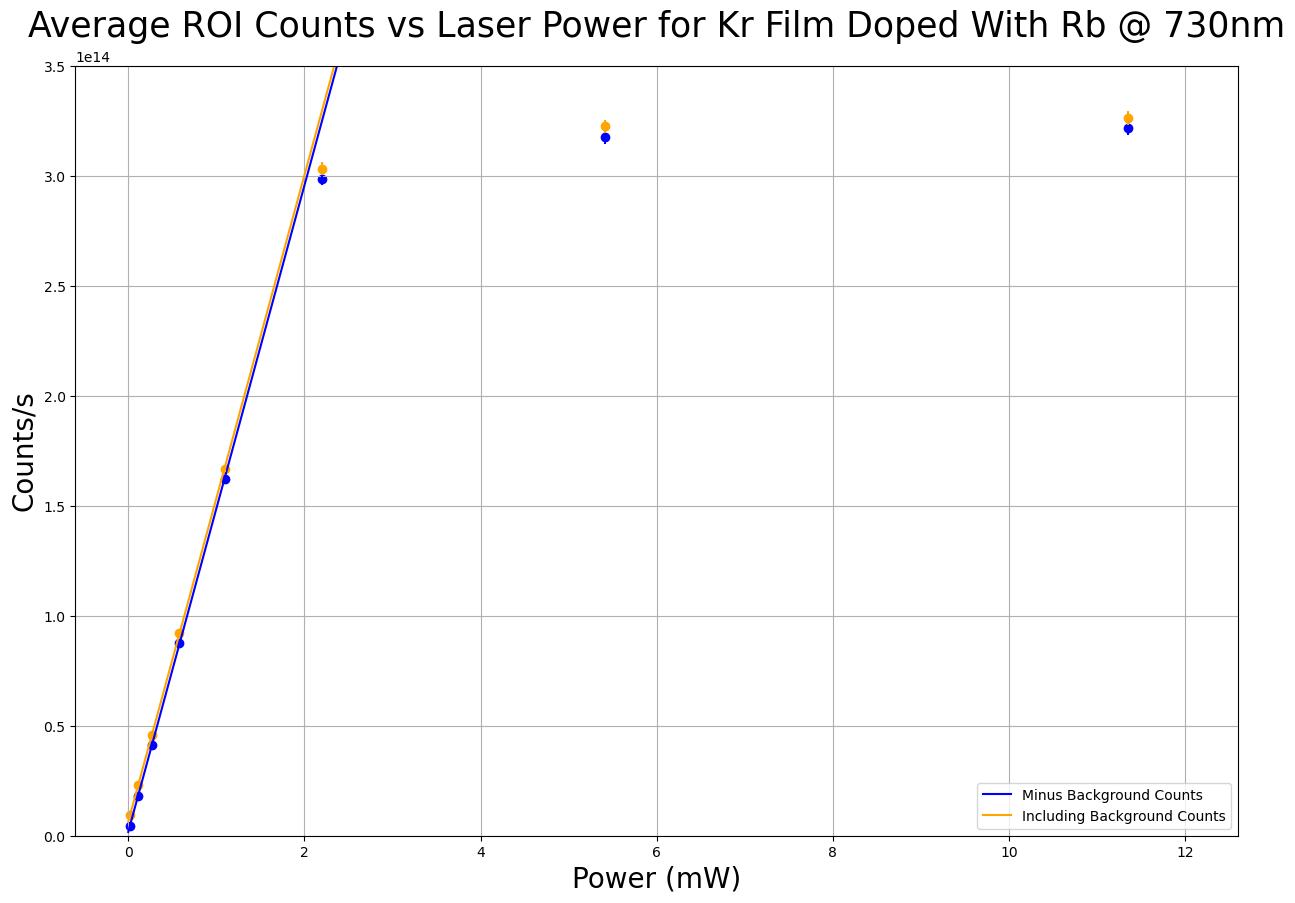

In [49]:
#plot
plt.figure(figsize=(15,10))
plt.scatter(averagePowerDoped, dccd_cps_no_bias,color='blue')
plt.plot(x_fit, linear_graph_dopedCCD*y_scale,color='blue', label='Minus Background Counts')
plt.errorbar(averagePowerDoped, dccd_cps_no_bias, xerr=uncertaintyPowerDoped, yerr=uncertainty_dopedROI+bias_uncertainty_ccd, linestyle='none', color='blue')
plt.scatter(averagePowerDoped, dccd_cps, color='orange')
plt.plot(x_fit, fit_doped_biased*y_scale, color='orange', label='Including Background Counts')
plt.errorbar(averagePowerDoped, dccd_cps, xerr=uncertaintyPowerDoped, yerr=uncertainty_dopedROI, linestyle='none', color='orange')
plt.ylim(0,3.5e14)
plt.grid()
plt.title("Average ROI Counts vs Laser Power for Kr Film Doped With Rb @ 730nm", fontsize=25, pad=10)
plt.xlabel("Power (mW)",fontsize=20) 
plt.ylabel("Counts/s",fontsize=20)
plt.legend()
plt.show()

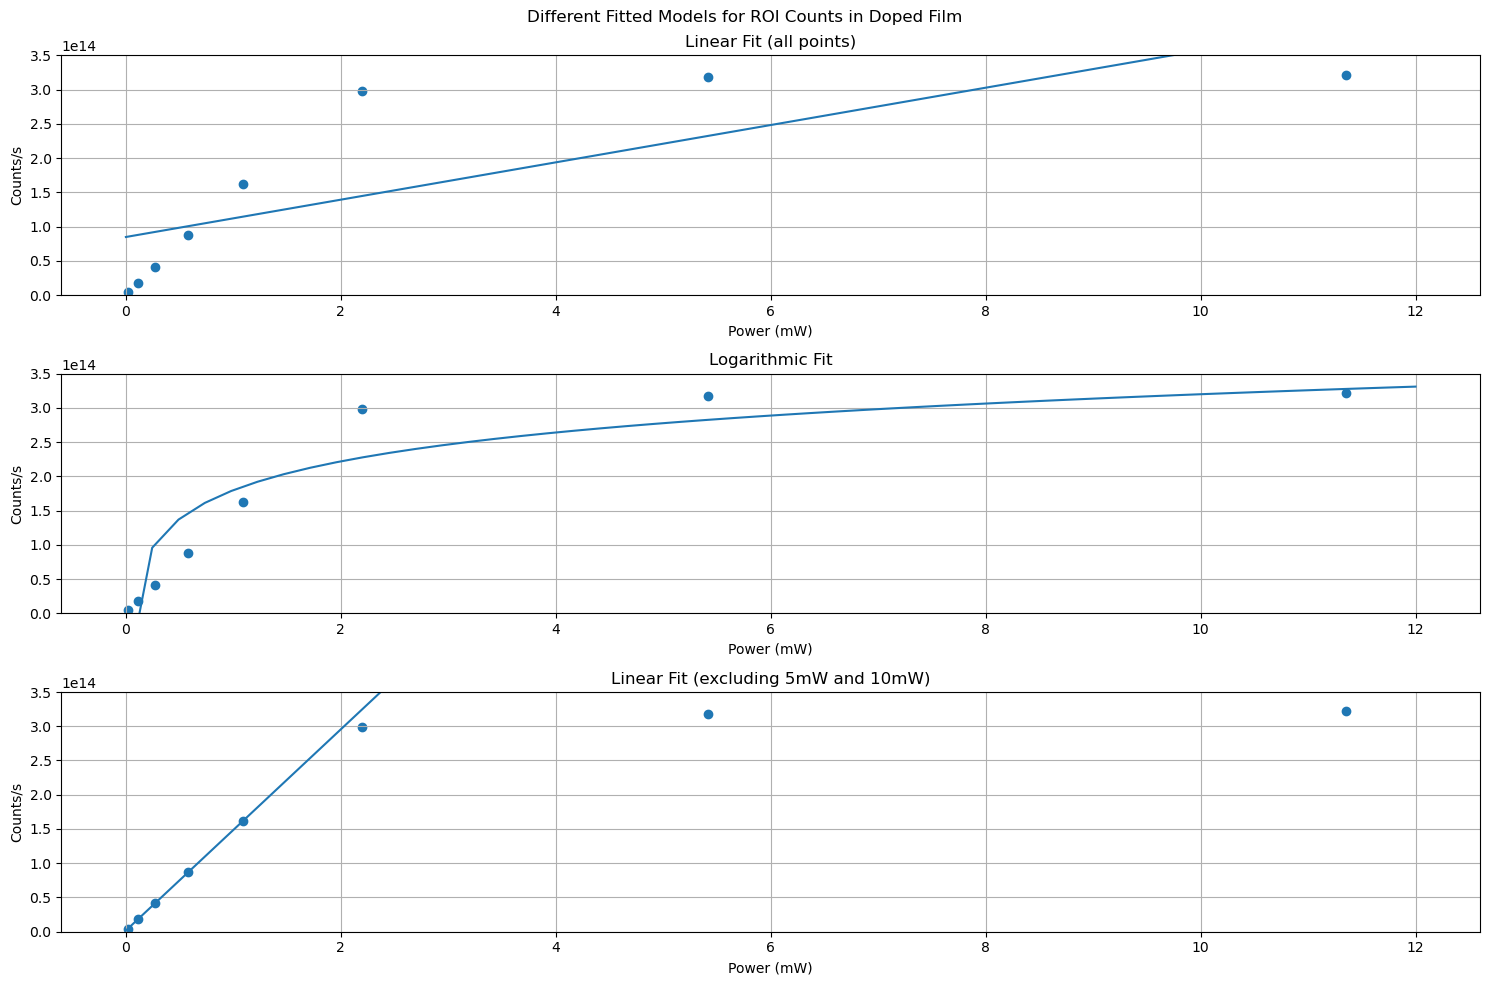

In [38]:
#comparison of different models for ROI counts
plt.figure(figsize=(15,10))
plt.suptitle("Different Fitted Models for ROI Counts in Doped Film")

#linear modeling for all points
ax = plt.subplot(3,1,1)
ax.set_ylim(0,3.5e14)
ax.set_ylabel("Counts/s")
ax.set_xlabel("Power (mW)")
plt.title("Linear Fit (all points)")
plt.grid()
plt.scatter(averagePowerDoped, dccd_cps_no_bias)
plt.plot(x_fit, linear_fit_dopedCCD*y_scale)

#log model
ax1 = plt.subplot(3,1,2)
ax1.set_ylim(0,3.5e14)
ax1.set_ylabel("Counts/s")
ax1.set_xlabel("Power (mW)")
plt.title("Logarithmic Fit")
plt.grid()
plt.scatter(averagePowerDoped, dccd_cps_no_bias)
plt.plot(x_fit, log_fit_dopedCCD*y_scale)

#linear model excluding saturated points (5mW and 10mW)
ax2 = plt.subplot(3,1,3)
ax2.set_ylim(0,3.5e14)
ax2.set_ylabel("Counts/s")
ax2.set_xlabel("Power (mW)")
plt.title("Linear Fit (excluding 5mW and 10mW)")
plt.grid()
ax2.scatter(averagePowerDoped, dccd_cps_no_bias)
ax2.plot(x_fit, linear_graph_dopedCCD*y_scale)
plt.tight_layout()

Text(0, 0.5, 'Counts/s')

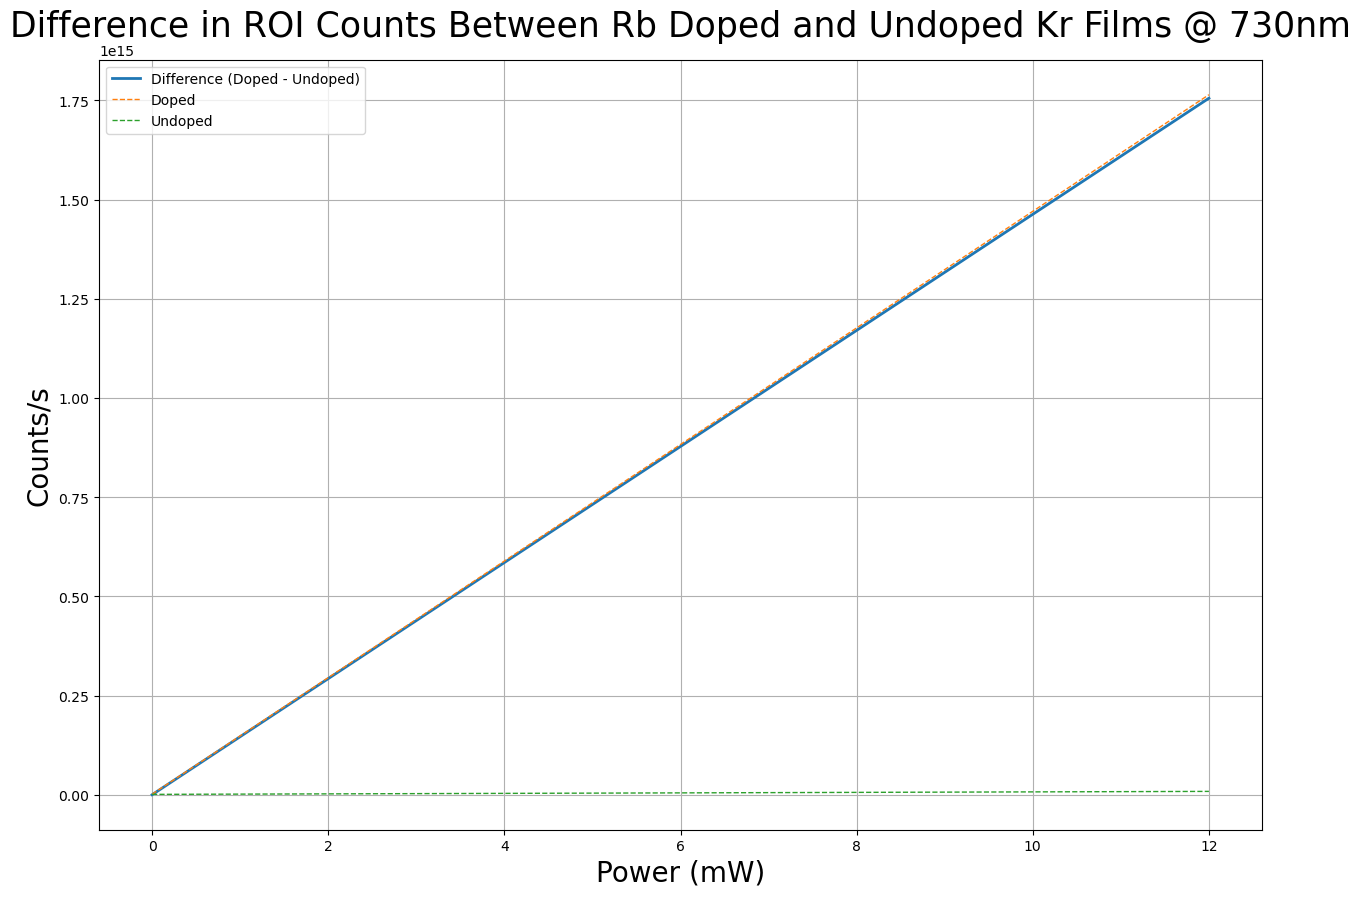

In [50]:
#plot difference between doped and undoped films for ROI
plt.figure(figsize=(15,10))
plt.plot(x_fit, np.array((linear_graph_dopedCCD*y_scale))-np.array((fit_undopedCCD*y_scale)),linewidth=2, label='Difference (Doped - Undoped)')
plt.plot(x_fit, linear_graph_dopedCCD*y_scale, linewidth=1, linestyle='--', label='Doped')
plt.plot(x_fit, fit_undopedCCD*y_scale, linewidth=1, linestyle='--', label='Undoped')
plt.legend()
plt.grid()
plt.title("Difference in ROI Counts Between Rb Doped and Undoped Kr Films @ 730nm", fontsize=25)
plt.xlabel("Power (mW)",fontsize=20)
plt.ylabel("Counts/s",fontsize=20)

ROI counts as percentage of total: [12.56360516 15.47349181 16.36265421 16.57301735 16.65237304 15.44263125
  8.44196256  7.23686072]


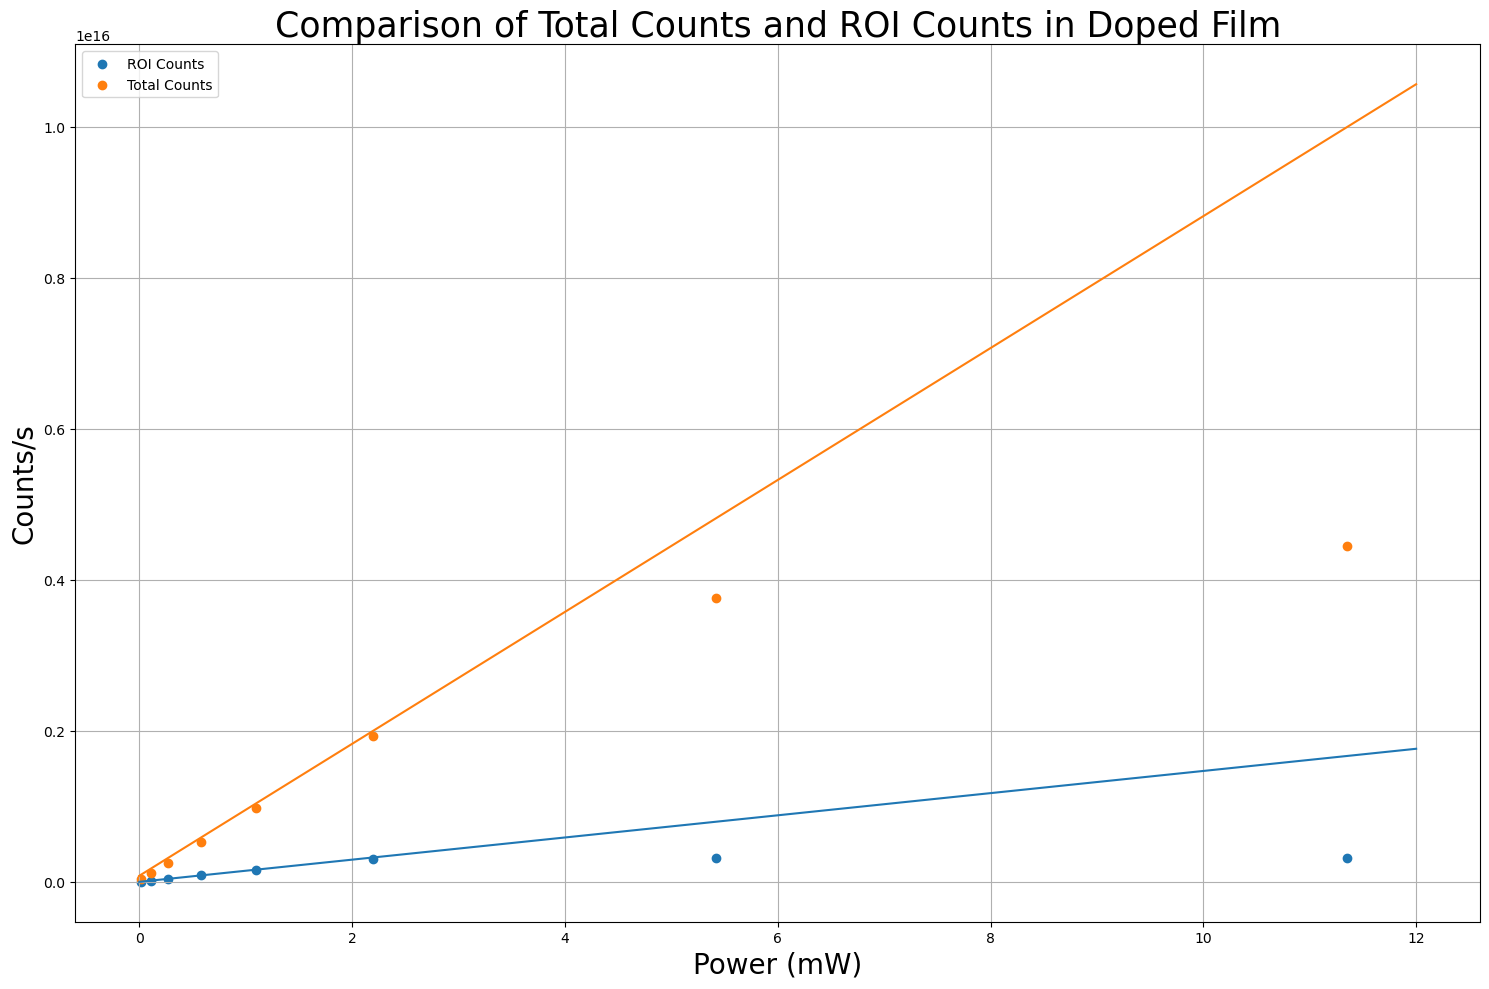

In [40]:
#plot comparison between total counts (minus background) and ROI counts
plt.figure(figsize=(15,10))
plt.scatter(averagePowerDoped, dccd_cps_no_bias,label='ROI Counts')
plt.plot(x_fit, linear_graph_dopedCCD*y_scale)
plt.scatter(averagePowerDoped, cpsDopedNoBias, label='Total Counts')
plt.plot(x_fit, fit_doped)
#plt.yscale('log')
plt.grid()
plt.xlabel("Power (mW)", fontsize=20)
plt.ylabel("Counts/s",fontsize=20)
plt.title("Comparison of Total Counts and ROI Counts in Doped Film",fontsize=25)
plt.legend()
plt.tight_layout()
print("ROI counts as percentage of total:", (dccd_cps_no_bias/cpsDopedNoBias)*100) 